# Portofolio construction and Strategy backtest

In [112]:
# Import
import numpy as np
import pandas as pd
from typing import List, Optional, Tuple, Dict
from scipy.stats import spearmanr, norm
from sklearn.linear_model import LinearRegression
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

def get_valid_segments_fixed(series):
    mask = series.notna().to_numpy()
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0] # returns all indexes that satisfies the condition
    ends = np.where(diff == -1)[0]
    return list(zip(starts, ends)) # note that 0-based [start, end)

def preprocessing_rolling(s, window=150, tolerance=8):
    """"
    Outliers are identified based on deviations from the rolling median, scaled by the median absolute deviation (MAD), 
    computed over a rolling window using **only past observations (i.e., no look-ahead bias).**

    Detected outliers are **clipped in log-return space to boundary values to avoid introducing artificial price paths**, 
    while preserving the temporal structure of the series.
    """
    # set center to False, uses the right edge of the window index
    rolling_median = s.rolling(window=window, center=False, min_periods = window).median()
    # requires full-sized window
    def get_mad(x):
        m = np.nanmedian(x)
        return np.nanmedian(np.abs(x - m))
        
    rolling_mad = s.rolling(window=window, center=False, min_periods = window).apply(get_mad)
    # scale MAD
    upper = rolling_median + tolerance * (1.4826 * rolling_mad)
    lower = rolling_median - tolerance * (1.4826 * rolling_mad)
    s_clean = s.clip(lower=lower, upper=upper)

    edge = window # only the left margin part with the whole window size
    s_clean.iloc[:edge] = preprocessing_global(s.iloc[:window], tolerance)
    return s_clean

def preprocessing_global(s, tolerance=8):        
    # global MAD
    global_median = np.nanmedian(s)
    deviation = np.nanmedian(np.abs(s - global_median))
    upper = global_median + tolerance * (1.4826 * deviation)
    lower = global_median - tolerance * (1.4826 * deviation)
    s_clean = np.clip(s, lower, upper) # clipping（8×MAD）
    return s_clean


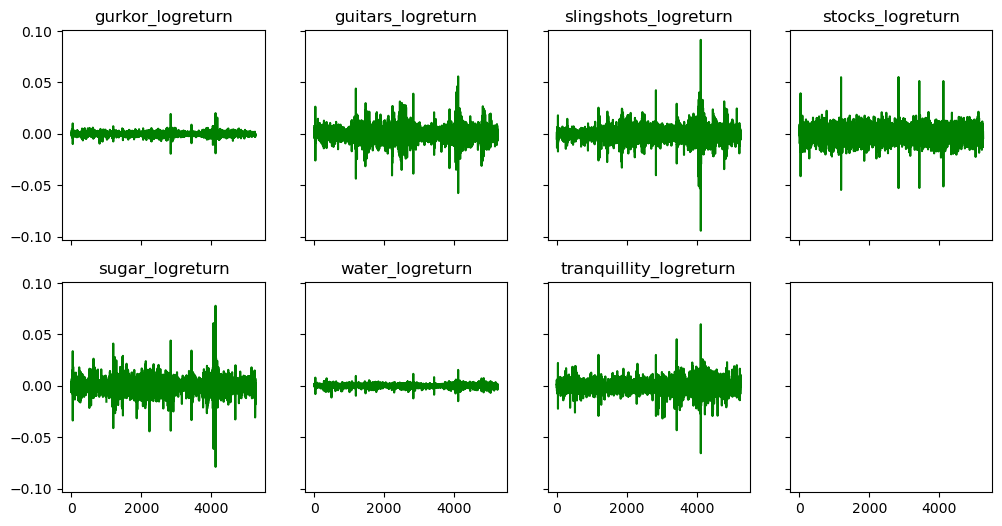

In [113]:
RISK_FREE_RATE_ANNUAL = 0.03
TRADING_DAYS = 252 
DB_PATH = Path("spiff_data.db")
TABLE_NAME = "transformed_data"

with duckdb.connect(DB_PATH) as conn:
    cols = conn.execute("DESCRIBE transformed_data").df()["column_name"].tolist()
    val_cols = [c for c in cols if "logreturn" in c]
    df = conn.execute(f"SELECT day, {', '.join(val_cols)} FROM {TABLE_NAME}").df()

# Handling missing values
df_trunc = df.set_index("day").loc[:5255]

# Preprocessing on log-return series
df_clean = df_trunc.copy()
for i, col in enumerate(val_cols):
    col_idx = df_clean.columns.get_loc(col)
    segments = get_valid_segments_fixed(df_trunc[col]) 
    for st, ed in segments:
        if ed - st >= 225: # 1.5 window_size
            # Note that center=False to aviod data leakage and uses global MAD for the whole left marginal region (differs to the preprocessing in task1)
            df_clean.iloc[st:ed, col_idx]= preprocessing_rolling(df_trunc[col][st:ed])
        else:
            df_clean.iloc[st:ed, col_idx]= preprocessing_global(df_trunc[col][st:ed])
fig, axes = plt.subplots(2,4, figsize=[12,6], sharex=True, sharey=True)
axes = axes.flatten()
for i, col in enumerate(val_cols):
    ax1 = axes[i]
    ax1.plot(df_clean.index, df_clean[col], color='green')
    ax1.set_title(f"{col}")

In [114]:
# Reconstruct the cleaned prices: P_t = P_0 * exp(cumsum(cleaned_logreturns))
df = pd.read_csv("./spiff_data-2.csv")
df_prices_clean = pd.DataFrame(index=df_clean.index)
for col in val_cols:
    r = df_clean[col]
    valid = r.notna()
    group = (valid != valid.shift()).cumsum()
    price_series = pd.Series(index=r.index, dtype=float)
    asset = col.replace("_logreturn", "")
    for g in group[valid].unique():
            seg = r[group == g].dropna()
            idx = seg.index
            st = idx[0]
            
            # anchor price
            if st == r.index[0]:
                p0 = df[asset].iloc[0]
            else:
                p0 = df[asset].loc[st - 1]
            price_series.loc[idx] = p0 * np.exp(seg.cumsum())

    df_prices_clean[asset] = price_series
df_prices_clean.describe()

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5203.000000,5203.000000,5203.000000,5203.000000,5203.000000,5203.000000,5203.000000
mean,7.498377,4.143764,2.914301,9.025684,3.081164,5.067048,9.630211
std,0.827245,0.628412,0.402496,1.039385,0.340758,0.671986,1.209027
min,6.141726,2.751996,2.073113,7.590643,2.328301,3.818079,7.262149
25%,6.770293,3.690061,2.670322,8.300532,2.766786,4.889298,8.733390
50%,7.541167,4.249341,2.902988,8.695934,3.109259,5.207483,9.279372
75%,8.027851,4.606140,3.211496,9.334694,3.400765,5.479982,10.535837
max,9.234643,5.564704,3.895213,12.296350,3.689817,6.301241,12.775682


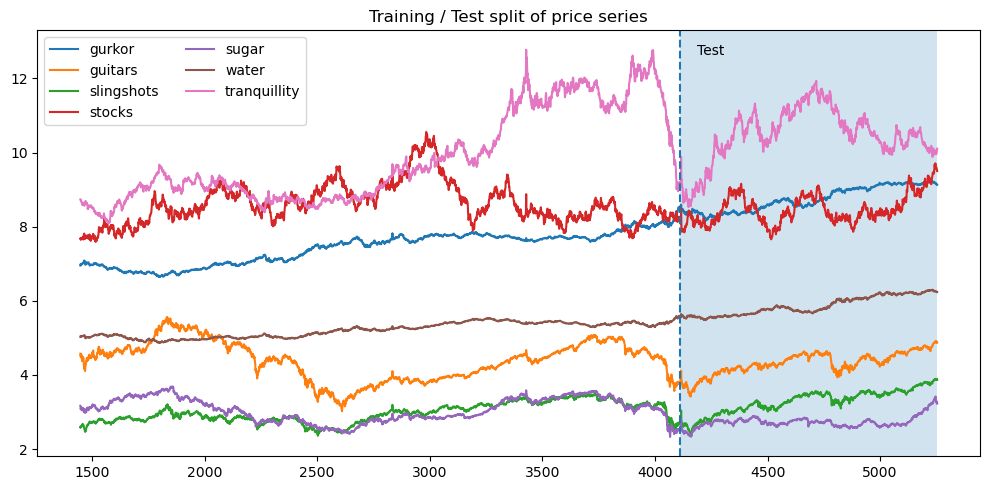

training: 2664 test: 1142 ratio: 2.3327495621716285


In [115]:
# find the global common series and split into 7:3 training and test sequence
asset_cols = [i.replace("_logreturn", "") for i in val_cols]
global_st, global_ed = -np.inf, np.inf
for i in asset_cols:
    splits = get_valid_segments_fixed(df_prices_clean[i])
    largest = sorted(splits, key=lambda x:x[1] - x[0], reverse=True)[0]
    if global_st < largest[0]:
        global_st = largest[0]
    if global_ed > largest[1]:
        global_ed = largest[1]
        
prices = df_prices_clean.reindex(columns=asset_cols).iloc[global_st:global_ed]
split = int(len(prices) * 0.7)
train_prices = prices.iloc[:split]
test_prices  = prices.iloc[split:]
fig, ax = plt.subplots(figsize=(10, 5))
time = np.arange(global_st, global_ed)
for col in asset_cols:
    ax.plot(time, prices[col], label=col)
# test 
ax.axvspan(global_st + split, global_st + len(prices) - 1, alpha=0.2)
# split line
ax.axvline(global_st + split,linestyle="--")
# annotation
ax.text(global_st + split + len(prices)*0.02, ax.get_ylim()[1] * 0.95, "Test")
ax.set_title("Training / Test split of price series")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()
print("training:", len(train_prices),"test:", len(test_prices), "ratio:", len(train_prices)/len(test_prices))

#### Candidates

In [116]:
from sklearn.decomposition import PCA
from statsmodels.stats.diagnostic import het_arch

def compute_hurst(col, lags=None):
    s = col.to_numpy()

    if lags is None:
        max_lag = len(s) // 4
        if max_lag < 10:
            return np.nan
        lags = np.unique(np.floor(np.logspace(np.log10(10), np.log10(max_lag), 20)).astype(int))
    valid_lags, rs = [], []
    for lag in lags:
        chunks = [s[i:i+lag] for i in np.arange(0, len(s) - lag, lag)]
        rs_vals = []
        for chunk in chunks:
            if len(chunk) < 2: continue
            mean_adj = chunk - chunk.mean()
            cumdev   = np.cumsum(mean_adj)
            r        = cumdev.max() - cumdev.min()
            std      = chunk.std(ddof=1)     # unbiased
            if std > 0:
                rs_vals.append(r / std)
        if rs_vals:
            rs.append(np.mean(rs_vals))
            valid_lags.append(lag)

    if len(rs) < 2:
        return np.nan
    
    hurst, _ = np.polyfit(np.log(valid_lags), np.log(rs), 1)
    return hurst


def trend_autocorr(col, horizons=(5, 10, 20, 40), lags=(1, 2, 5), min_periods=100):
    results = []
    for h in horizons:
        r_h = col.diff(h)
        for k in lags:
            df = pd.DataFrame({
                "r_h":     r_h,
                "r_h_lag": r_h.shift(k)
            }).dropna()

            if len(df) < min_periods:
                continue 
            
            corr = df["r_h"].corr(df["r_h_lag"]) 
            results.append({"horizon": h, "lag": k, "corr": corr})

    if not results:
        return np.nan

    df_res = pd.DataFrame(results)
    return df_res["corr"]

In [117]:
def select_ma_candidates(df, cols):
    """
    Select moving average crossover candidates using continuous Z-score normalization.
    Filters assets with hurst > 0.50 and scores by normalized trend characteristics.
    """
    summary = dict()
    for col in cols:
        s = df[col]
        
        # 1. Hurst > 0.5 for trend persistence，～0.5 random walk, < 0.5 for mean-reverting
        hurst = compute_hurst(np.log(s).diff().dropna())

        # 2. trend autocorrelation on **log-price**, >0 Trend Persistence (Momentum)
        trend_ac = trend_autocorr(np.log(s))
        trend_ac_mean = trend_ac.mean()

        # 3. Sign persistence (directional change autocorrelation)
        s_logreturn = np.log(s).diff().dropna()
        sign_persist = (s_logreturn * s_logreturn.shift(1) > 0).mean()

        summary[col] = {
            "hurst":        hurst,
            "trend_ac":     trend_ac_mean,
            "sign_persist": sign_persist,
        }
    
    # Convert to DataFrame for continuous normalization
    df_stats = pd.DataFrame.from_dict(summary, orient='index')
    
    # Baseline filter: keep only assets with hurst > 0.50 (avoiding mean-reverting assets)
    df_valid = df_stats[df_stats['hurst'] > 0.50].copy()

    if df_valid.empty:
        # Fallback: return all candidates if none pass baseline
        df_valid = df_stats.copy()
    
    # Cross-sectional Z-score normalization (standardize each metric)
    df_norm = (df_valid - df_valid.mean()) / df_valid.std()
    df_norm = df_norm.fillna(0)  # Handle NaN from std=0
    
    # Combined continuous score (equal weight across factors)
    df_valid['combined_score'] = df_norm['hurst'] + df_norm['trend_ac'] + df_norm['sign_persist']
    
    # Sort by combined score (primary), then by hurst as tie-breaker (secondary)
    df_valid = df_valid.sort_values(by=['combined_score', 'hurst'], ascending=False)
    
    # Return as list of tuples (asset_name, combined_score)
    candidates = [(idx, row['combined_score']) for idx, row in df_valid.iterrows()]
    
    # Update summary with the new continuous scores
    for asset, score in candidates:
        summary[asset]['continuous_score'] = score
    
    return summary, candidates

In [118]:
def select_bo_candidates(df, cols):
    """
    Select Donchian breakout candidates using continuous Z-score normalization.
    Filters assets with strong trend + high breakout success + sufficient volatility.
    """
    summary = dict()
    for col in cols:
        s = df[col]
        # 1. Hurst > 0.5 for trend persistence
        hurst = compute_hurst(np.log(s).diff().dropna())

        # 2. trend autocorrelation on **log-price**
        trend_ac = trend_autocorr(np.log(s))
        trend_ac_mean = trend_ac.mean()

        # 3. Sign persistence (directional change autocorrelation)
        s_logreturn = np.log(s).diff().dropna()
        sign_persist = (s_logreturn * s_logreturn.shift(1) > 0)
        sign_persist_ok = (sign_persist  > 0.52).sum()/len(sign_persist)
        
        # 4. Breakout hit rate - empirical success rate of breakout events
        high        = s.rolling(100).max() # rolling 100-period maximum price
        low         = s.rolling(100).min()
        breakout = (s >= high.shift(1) * 0.99) # soft breakout event, near the high
        post_ret = np.log(s).diff().shift(-1)[breakout]      # post-Event Return
        bo_hit_rate = (post_ret > 0).mean()

        # 5. Range width - measures consolidation/volatility for meaningful breakouts
        range_width = (high - low) / s.rolling(100).std()
        width_ok = (range_width.dropna() > 1.5).sum()/len(range_width.dropna())
       
        # 6. Tail ratio - ensures sufficient price movement magnitude for breakout signals
        tail_ratio = (s_logreturn.abs().rolling(100).quantile(0.95) /
              s_logreturn.abs().rolling(100).median().replace(0, np.nan))
        tail_ratio_mean = tail_ratio.dropna().mean()
        
        summary[col] = {
            "hurst":        hurst,
            "trend_ac":     trend_ac_mean,
            "sign_persist": sign_persist_ok,
            "bo_hit_rate":  bo_hit_rate,
            "width_ok":     width_ok,
            "tail_ratio":   tail_ratio_mean,
        }
    
    # Convert to DataFrame for continuous normalization
    df_stats = pd.DataFrame.from_dict(summary, orient='index')
    
    # Baseline filter: keep only assets with strong trend + good breakout characteristics
    df_valid = df_stats[
        (df_stats['hurst'] > 0.50) &      # Trend persistence
        (df_stats['bo_hit_rate'] > 0.50) & # Meaningful breakout success
        (df_stats['tail_ratio'] > 1.3)     # Sufficient volatility for signals
    ].copy()
    
    if df_valid.empty:
        # Fallback: return all candidates if none pass baseline
        df_valid = df_stats.copy()
    
    # Cross-sectional Z-score normalization
    df_norm = (df_valid - df_valid.mean()) / df_valid.std()
    df_norm = df_norm.fillna(0)  # Handle NaN from std=0
    
    # Combined continuous score (equal weight across factors)
    df_valid['combined_score'] = (
        df_norm['hurst'] + 
        df_norm['trend_ac'] + 
        df_norm['sign_persist'] + 
        df_norm['bo_hit_rate'] + 
        df_norm['width_ok'] + 
        df_norm['tail_ratio']
    )
    
    # Sort by combined score (primary), then by bo_hit_rate as tie-breaker (secondary)
    df_valid = df_valid.sort_values(by=['combined_score', 'bo_hit_rate'], ascending=False)
    
    # Return as list of tuples (asset_name, combined_score)
    candidates = [[idx, row['combined_score']] for idx, row in df_valid.iterrows()]
    
    # Update summary with the new continuous scores
    for asset, score in candidates:
        summary[asset]['continuous_score'] = score
    
    return summary, candidates

In [119]:
def show_ma(ma_summary, ma_candidates):
    print("\nMA CANDIDATES:")
    print(f"\n{'Asset':<12} {'Hurst':>10} {'Trend AC':>10} {'Sign Pers':>10} {'Combined Score':>15}")
    print("-" * 70)
    for asset, _ in ma_candidates:
        stats = ma_summary[asset]
        print(f"{asset:<12} {stats['hurst']:>10.3f} {stats['trend_ac']:>10.3f} {stats['sign_persist']:>10.3f} {stats['continuous_score']:>15.3f}")
def show_bo(bo_summary, bo_candidates):
    print("\nBO CANDIDATES:")
    print(f"\n{'Asset':<12} {'Hurst':>10} {'Trend AC':>10} {'BO Hit':>10} {'Width OK':>10} {'Tail Ratio':>11} {'Score':>10}")
    print("-" * 70)
    for asset, _ in bo_candidates:
        stats = bo_summary[asset]
        print(f"{asset:<12} {stats['hurst']:>10.3f} {stats['trend_ac']:>10.3f} {stats['bo_hit_rate']:>10.3f} {stats['width_ok']:>10.3f} {stats['tail_ratio']:>11.3f} {stats['continuous_score']:>10.3f}")

#### Allocation

In [120]:
def normalize_weights(weights: pd.Series, long_only: bool = True, max_weight: Optional[float] = None) -> pd.Series:
    w = weights.astype(float).copy()
    if long_only:
        w = w.clip(lower=0)
    total = w.sum()
    if total == 0:
        return w
    w = w / total
    if max_weight is not None:
        w = w.clip(upper=max_weight)
        if w.sum() > 0:
            w = w / w.sum()
    return w

def normalize_weight_frame(weights: pd.DataFrame, long_only: bool = True, max_weight: Optional[float] = None) -> pd.DataFrame:
    w = weights.astype(float).copy()
    if long_only:
        w = w.clip(lower=0)
    row_sum = w.sum(axis=1).replace(0, np.nan)
    w = w.div(row_sum, axis=0).fillna(0.0)
    if max_weight is not None:
        w = w.clip(upper=max_weight)
        row_sum = w.sum(axis=1).replace(0, np.nan)
        w = w.div(row_sum, axis=0).fillna(0.0)
    return w

def signal_strength_to_risky_budget(signals: pd.DataFrame, min_risky_budget: float = 0.0, max_risky_budget: float = 1.0, window: int = 20) -> pd.Series:
    signed_strength = signals.mean(axis=1)
    signed_strength = signed_strength.rolling(window=window, min_periods=1).mean()
    signed_strength = signed_strength.clip(-1.0, 1.0)
    scaled = (signed_strength + 1.0) / 2.0 # Map [-1, 1] -> [0, 1]
    scaled = scaled.clip(0.0, 1.0).fillna(0.0)
    return min_risky_budget + (max_risky_budget - min_risky_budget) * scaled

def attach_cash_budget(asset_weights: pd.DataFrame, risky_budget: pd.Series | float) -> pd.DataFrame:
    w = normalize_weight_frame(asset_weights, long_only=True)

    if np.isscalar(risky_budget):
        risky_budget = pd.Series(float(risky_budget), index=w.index)

    risky_budget = risky_budget.reindex(w.index).fillna(0.0).clip(0.0, 1.0)

    risky = w.mul(risky_budget, axis=0)
    cash = 1.0 - risky.sum(axis=1)
    cash = cash.clip(lower=0.0, upper=1.0)

    out = risky.copy()
    out["cash"] = cash

    total = out.sum(axis=1).replace(0, np.nan)
    out = out.div(total, axis=0).fillna(0.0)
    return out

def handle_residual_cash(
    asset_weights: pd.DataFrame,
    signals: pd.DataFrame,
    min_risky_budget: float = 0.0,
    max_risky_budget: float = 1.0,
    window: int = 20,
) -> pd.DataFrame:
    risky_budget = signal_strength_to_risky_budget(
        signals,
        min_risky_budget=min_risky_budget,
        max_risky_budget=max_risky_budget,
        window=window,
    )
    return attach_cash_budget(asset_weights, risky_budget)

In [132]:
def inverse_vol_allocation(
    returns: pd.DataFrame,
    lookback: int = 60,
    min_periods: Optional[int] = None,
    max_weight: Optional[float] = None,
) -> pd.DataFrame:
    min_periods = lookback if min_periods is None else min_periods
    vol = returns.rolling(lookback, min_periods=min_periods).std()
    inv_vol = 1 / vol.replace(0, np.nan)
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    if max_weight is not None:
        weights = weights.clip(upper=max_weight)
        weights = weights.div(weights.sum(axis=1), axis=0)
    return normalize_weight_frame(weights, long_only=True, max_weight=max_weight)


def signal_based_allocation(
    signals: pd.DataFrame,
    continuous: bool = False,
    normalize: bool = True
) -> pd.DataFrame:
    """
    Weight allocation based on strategy signals (binary/continuous/ranked).
    """
    weights = signals.copy()
    
    if continuous and normalize:
        # for each time points, the max/min signals across assets
        min_vals = weights.min(axis=1, skipna=True).values[:, None]
        max_vals = weights.max(axis=1, skipna=True).values[:, None]
        denom = (max_vals - min_vals + 1e-10)
        weights = (weights - min_vals) / denom
    weights = weights.fillna(0.0)
    return normalize_weight_frame(weights, long_only=True)


def inverse_volatility_adjusted_allocation(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    window: int = 60,
    min_periods: Optional[int] = None
) -> pd.DataFrame:
    """
    Combine signal intensity with inverse-volatility scaling for risk-parity.
    """
    inv_vol_weights = inverse_vol_allocation(returns, window, min_periods)
    signal_weights = signal_based_allocation(signals, continuous=True, normalize=True)
    combined = inv_vol_weights.reindex_like(signal_weights).fillna(0.0) * signal_weights
    return normalize_weight_frame(combined, long_only=True)


def equal_weight_allocation(assets: list[str], max_weight: Optional[float] = None) -> pd.Series:
    if len(assets) == 0:
        return pd.Series(dtype=float)
    weights = pd.Series(1 / len(assets), index=assets, dtype=float)
    return normalize_weights(weights, long_only=True, max_weight=max_weight)


def covariance_weighted_allocation(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    lookback: int = 60,
    min_periods: Optional[int] = None,
    max_weight: Optional[float] = None,
    regularization: float = 0.01,
) -> pd.Series:
    """
    Row-wise covariance-aware allocation.
    For each date t:
    - use signal row at t
    - use trailing return window up to t
    - compute one weight row
    - stack all rows into a full weight frame
    """
    min_periods = lookback if min_periods is None else min_periods

    returns = returns.copy()
    signals = signals.copy()
    base = pd.DataFrame(0.0, index=returns.index, columns=returns.columns)
    for i, dt in enumerate(returns.index):
        signal_row = signals.loc[dt].fillna(0.0)                   # use label-based lookup
        selected_cols = signal_row[signal_row > 0].index.tolist()  # now a list of asset column names
        if len(selected_cols)==0:
                        continue

        hist_returns = returns.iloc[max(0, i - lookback + 1): i + 1][selected_cols]
        if len(hist_returns) < min_periods:
            w_row = equal_weight_allocation(list(selected_cols), max_weight=max_weight)
        else:
            cov_matrix = hist_returns.cov()
            if cov_matrix.empty or cov_matrix.isnull().any().any():
                w_row = equal_weight_allocation(list(selected_cols), max_weight=max_weight)
            else:
                inv_vol = 1 / hist_returns.std().replace(0, np.nan)
                inv_vol = inv_vol.fillna(0.0)
                try:
                    cov_inv = np.linalg.inv(cov_matrix + regularization * np.eye(len(cov_matrix)))
                    weights_vec = cov_inv @ inv_vol.values
                    weights_vec = weights_vec / weights_vec.sum() if weights_vec.sum() > 0 else weights_vec
                    w_row = pd.Series(weights_vec, index=selected_cols, dtype=float)
                except np.linalg.LinAlgError:
                    w_row = equal_weight_allocation(list(selected_cols), max_weight=max_weight)

        w_row = w_row.reindex(returns.columns).fillna(0.0).astype(float)
        if max_weight is not None:
            w_row = w_row.clip(upper=max_weight)
            if w_row.sum() > 0:
                w_row = w_row / w_row.sum()

        base.iloc[i] = w_row.values

    return normalize_weight_frame(base, long_only=True, max_weight=max_weight)

#### Signal

In [165]:
def moving_average_crossover_signal(prices: pd.DataFrame, short_window: int = 20, long_window: int = 50, use_ema: bool = False, threshold: float = 0.0) -> pd.DataFrame:
    short_ma = prices.shift(1).ewm(span=short_window, adjust=False).mean() if use_ema else prices.rolling(short_window).mean()
    long_ma = prices.shift(1).ewm(span=long_window, adjust=False).mean() if use_ema else prices.rolling(long_window).mean()
    diff = short_ma - long_ma
    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    signal[diff > threshold] = 1.0
    signal[diff < -threshold] = -1.0
    return signal

def donchian_breakout_signal(prices: pd.DataFrame, lookback: int = 20) -> pd.DataFrame:
    upper = prices.shift(1).rolling(lookback).max()
    lower = prices.shift(1).rolling(lookback).min()
    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    signal[prices > upper] = 1.0
    signal[prices < lower] = -1.0
    return signal

#### Metrics

In [123]:
def annualized_return(returns: pd.Series | pd.DataFrame, periods_per_year: int = TRADING_DAYS) -> float | pd.Series:
    compounded = (1 + returns.fillna(0)).prod()
    n_periods = returns.dropna().shape[0]
    if n_periods == 0:
        return np.nan
    return compounded ** (periods_per_year / n_periods) - 1


def annualized_volatility(returns: pd.Series | pd.DataFrame, periods_per_year: int = TRADING_DAYS) -> float | pd.Series:
    return returns.std(skipna=True) * np.sqrt(periods_per_year)


def sharpe_ratio(returns: pd.Series, risk_free_rate_annual: float = RISK_FREE_RATE_ANNUAL, periods_per_year: int = TRADING_DAYS) -> float:
    rf_period = risk_free_rate_annual / periods_per_year
    excess = returns.dropna() - rf_period
    vol = excess.std(ddof=1) # sample estimate
    if vol == 0 or np.isnan(vol):
        return np.nan
    return excess.mean() / vol * np.sqrt(periods_per_year)


def sortino_ratio(returns: pd.Series, risk_free_rate_annual: float = RISK_FREE_RATE_ANNUAL, periods_per_year: int = TRADING_DAYS) -> float:
    rf_period = risk_free_rate_annual / periods_per_year
    excess = returns.fillna(0) - rf_period
    downside = excess[excess < 0]
    downside_std = downside.std(ddof=0)
    if downside_std == 0 or np.isnan(downside_std):
        return np.nan
    return excess.mean() / downside_std * np.sqrt(periods_per_year)


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1 + returns.fillna(0)).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min()


def cagr(returns: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    total_return = (1 + returns.fillna(0)).prod() - 1
    n_years = returns.dropna().shape[0] / periods_per_year
    if n_years == 0 or total_return < -1:
        return np.nan
    return (1 + total_return) ** (1 / n_years) - 1


def calmar_ratio(returns: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    mdd = max_drawdown(returns)
    if mdd == 0 or np.isnan(mdd):
        return np.nan
    ann_ret = annualized_return(returns, periods_per_year=periods_per_year)
    return ann_ret / abs(mdd)


def win_rate(returns: pd.Series) -> float:
    wins = (returns > 0).sum()
    total = (returns != 0).sum()
    if total == 0:
        return np.nan
    return wins / total


def risk_reward_ratio(returns: pd.Series) -> float:
    avg_win = returns[returns > 0].mean()
    avg_loss = returns[returns < 0].mean()
    if avg_loss == 0 or np.isnan(avg_loss) or np.isnan(avg_win):
        return np.nan
    return avg_win / abs(avg_loss)


def profit_factor(returns: pd.Series) -> float:
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    if losses == 0:
        return np.inf if gains > 0 else np.nan
    return gains / losses


def expectancy(returns: pd.Series) -> float:
    wr = win_rate(returns)
    avg_win = returns[returns > 0].mean()
    avg_loss = returns[returns < 0].mean()
    if np.isnan(wr) or np.isnan(avg_win) or np.isnan(avg_loss):
        return np.nan
    return wr * avg_win - (1 - wr) * abs(avg_loss)


def strategy_summary(returns: pd.Series, risk_free_rate_annual: float = RISK_FREE_RATE_ANNUAL) -> pd.Series:
    return pd.Series({
        "annualized_return": annualized_return(returns),
        "cagr": cagr(returns),
        "annualized_volatility": annualized_volatility(returns),
        "sharpe_ratio": sharpe_ratio(returns, risk_free_rate_annual=risk_free_rate_annual),
        "sortino_ratio": sortino_ratio(returns, risk_free_rate_annual=risk_free_rate_annual),
        "calmar_ratio": calmar_ratio(returns),
        "max_drawdown": max_drawdown(returns),
        "profit_factor": profit_factor(returns),
        "win_rate": win_rate(returns),
        "risk_reward_ratio": risk_reward_ratio(returns),
        "expectancy": expectancy(returns),
        "cumulative_return": (1 + returns.fillna(0)).prod() - 1,
    })

In [124]:
def calculate_portfolio_returns(
    weights: pd.DataFrame,
    returns: pd.DataFrame,
    risk_free_rate_annual: float = RISK_FREE_RATE_ANNUAL,
) -> pd.Series:
    """
    Compute portfolio returns from time-varying weights, accounting for transaction costs.
    """
    # note that weight comes from signal.shift(1)
    cash_weight = weights["cash"].copy()
    cash_weight = cash_weight.reindex(returns.index).ffill().fillna(0)
    
    asset_weights = weights.drop(columns=["cash"])
    
    aligned_weights = asset_weights.reindex(returns.index).ffill().fillna(0)
    aligned_weights = aligned_weights.reindex(columns=returns.columns).fillna(0)

    rf_daily = risk_free_rate_annual / TRADING_DAYS # linear approx
    return (aligned_weights * returns.fillna(0)).sum(axis=1) + cash_weight * rf_daily


def calculate_cumulative_returns(
    returns: pd.Series,
    initial_capital: float = 1.0
) -> pd.Series:
    """
    Compute cumulative wealth (compound returns).
    """
    cumulative = (1 + returns).cumprod() * initial_capital
    return cumulative


def calculate_win_rate(portfolio_returns: pd.Series) -> float:
    """
    Win rate: percentage of periods with positive return.
    """
    return (portfolio_returns > 0).sum() / len(portfolio_returns) if len(portfolio_returns) > 0 else np.nan


def calculate_max_drawdown_with_dates(returns: pd.Series) -> Tuple[float, Tuple[int, int]]:
    """
    Maximum Drawdown with peak and trough indices.
    """
    cumulative = calculate_cumulative_returns(returns)
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / (running_max + 1e-10)
    mdd = drawdown.min()
    
    mdd_idx = drawdown.idxmin()
    peak_idx = running_max[:mdd_idx].idxmax()
    
    return mdd, (returns.index.get_loc(peak_idx), returns.index.get_loc(mdd_idx))


def calculate_summary_metrics(
    returns: pd.Series,
    asset_returns: Optional[pd.DataFrame] = None,
    risk_free_rate: float = RISK_FREE_RATE_ANNUAL,
    periods_per_year: int = TRADING_DAYS,
    name: str = "Strategy"
) -> Dict:
    """
    Compute comprehensive performance summary in one call.
    """
    metrics = {
        'name': name,
        'n_periods': len(returns),
        'start_date': returns.index[0] if hasattr(returns.index, '__getitem__') else None,
        'end_date': returns.index[-1] if hasattr(returns.index, '__getitem__') else None,
    }
    
    metrics['total_return'] = (1 + returns).prod() - 1
    metrics['annualized_return'] = annualized_return(returns, periods_per_year)
    metrics['cumulative_wealth'] = calculate_cumulative_returns(returns).iloc[-1]
    metrics['annualized_volatility'] = annualized_volatility(returns, periods_per_year)
    metrics['max_drawdown'] = max_drawdown(returns)
    metrics['win_rate'] = calculate_win_rate(returns)
    metrics['sharpe_ratio'] = sharpe_ratio(returns, risk_free_rate, periods_per_year)
    metrics['sortino_ratio'] = sortino_ratio(returns, risk_free_rate, periods_per_year)
    metrics['calmar_ratio'] = calmar_ratio(returns, periods_per_year)
    metrics['mean_daily_return'] = returns.mean()
    metrics['std_daily_return'] = returns.std()
    metrics['skewness'] = returns.skew()
    metrics['kurtosis'] = returns.kurtosis()
    
    return metrics


In [125]:
from scipy import stats
from scipy.stats import bootstrap

# Helper function to compute all metrics for a returns series
def calculate_metrics(returns, risk_free_rate=RISK_FREE_RATE_ANNUAL):
    """Compute comprehensive metrics for a returns series."""
    n = len(returns)
    daily_vol = returns.std(ddof=1)
    
    return {
        'mean_return': returns.mean(),
        'std_return': daily_vol,
        'sharpe_ratio': sharpe_ratio(returns, risk_free_rate),
        'sortino_ratio': sortino_ratio(returns, risk_free_rate),
        'max_drawdown': max_drawdown(returns),
        'calmar_ratio': calmar_ratio(returns),
        'win_rate': win_rate(returns),
        'profit_factor': profit_factor(returns),
        't_statistic': returns.mean() / (returns.std(ddof=1) / np.sqrt(n)) if returns.std(ddof=1) > 0 else 0,
        'p_value': 2 * (1 - stats.t.cdf(abs(returns.mean() / (returns.std(ddof=1) / np.sqrt(n))), df=n-1)) if returns.std(ddof=1) > 0 else 1.0,
    }

def evaluate_production_readiness(returns_is, returns_oos, weights):
    """
    Complete production readiness evaluation combining statistical confidence, 
    overfitting analysis, and operational feasibility.
    """
    metrics = {}
    
    # Compute comprehensive metrics for both periods
    is_metrics = calculate_metrics(returns_is)
    oos_metrics = calculate_metrics(returns_oos)
    metrics['is_metrics'] = is_metrics
    metrics['oos_metrics'] = oos_metrics
    
    # 1. Overfitting detection: IS/OOS Sharpe decay
    if is_metrics['sharpe_ratio'] > 0 and not np.isnan(oos_metrics['sharpe_ratio']):
        metrics['sharpe_decay_ratio'] = oos_metrics['sharpe_ratio'] / (is_metrics['sharpe_ratio'] + 1e-10)
    else:
        metrics['sharpe_decay_ratio'] = np.nan
    
    # Return gap
    metrics['return_gap'] = is_metrics['mean_return'] - oos_metrics['mean_return']
    
    # 2. Annual turnover (directly impacts profitability)
    daily_turnover = weights.diff().abs().sum(axis=1)
    metrics['annual_turnover'] = daily_turnover.mean() * 252
    
    # 3. Cost-adjusted Sharpe
    COST_PER_TURN = 0.001  # 10bps per turn
    cost_adjusted_returns = returns_oos - daily_turnover.reindex(returns_oos.index).fillna(0) * COST_PER_TURN
    metrics['sharpe_after_cost'] = sharpe_ratio(cost_adjusted_returns, RISK_FREE_RATE_ANNUAL)
    
    # 4. Max recovery days
    def max_recovery_days_helper(ret, exclude_incomplete=True):
        if ret is None or len(ret) == 0:
            return 0
        cum = (1 + ret.fillna(0)).cumprod()
        running_max = cum.cummax()
        underwater = cum < running_max

        if not underwater.any():
            return 0

        groups = (underwater != underwater.shift()).cumsum()
        max_rec = 0

        for _, grp_idx in underwater.groupby(groups).groups.items():
            if not underwater.iloc[underwater.index.get_loc(grp_idx[0])]:
                continue  # 跳过非水下段

            is_last_segment = grp_idx[-1] == underwater.index[-1]

            if exclude_incomplete and is_last_segment:
                continue  # 末尾未恢复段排除

            max_rec = max(max_rec, len(grp_idx))

        return int(max_rec)
    metrics['max_recovery_days'] = max_recovery_days_helper(returns_oos, exclude_incomplete=True)

    # 5. Rolling Sharpe stability
    rolling_sharpe = returns_oos.rolling(252).mean() / returns_oos.rolling(252).std() * np.sqrt(252)
    metrics['rolling_sharpe_std'] = rolling_sharpe.std()
    metrics['pct_periods_positive_sharpe'] = (rolling_sharpe > 0).sum() / rolling_sharpe.notna().sum() if rolling_sharpe.notna().sum() > 0 else np.nan
    
    # Production readiness checklist
    """Not available for negative sharpe of insample data
    readiness_checks = {
        'significant_oos_return': metrics['oos_metrics']['p_value'] < 0.05,
        'moderate_overfit': metrics['sharpe_decay_ratio'] > 0.5 if not np.isnan(metrics['sharpe_decay_ratio']) else False,
        'acceptable_turnover': metrics['annual_turnover'] < 5.0,  # < 500% annual
        'sharpe_after_cost_positive': metrics['sharpe_after_cost'] > 0,
        'recovery_reasonable': metrics['max_recovery_days'] < 252,  # Within 1 year
        'stable_rolling_sharpe': metrics['rolling_sharpe_std'] < abs(is_metrics['sharpe_ratio']) * 0.5,  # Std < 50% of mean
    }
        
    metrics['readiness_checks'] = readiness_checks
    metrics['readiness_score'] = sum(readiness_checks.values()) / len(readiness_checks)
    print("\nProduction Readiness Checklist:")
    print("-" * 50)
    for check, passed in readiness_checks.items():
        status = "T" if passed else "F"
        print(f"{status} {check:40s} {passed}")
    print(f"\nOverall Readiness Score: {metrics['readiness_score']*100:.1f}%")
    """

    # Print summary
    print(f"{'':25s} {'IS':>12} {'OOS':>12}")
    print("-" * 50)
    print(f"{'OOS t-stat':25s} {'':>12} {oos_metrics['t_statistic']:>12.2f}")

    print(f"{'Sharpe':25s} {is_metrics['sharpe_ratio']:>12.3f} {oos_metrics['sharpe_ratio']:>12.3f}")
    print(f"{'OOS/IS Sharpe':25s} {'':>12} {metrics['sharpe_decay_ratio']:>12.2f}")
    print(f"{'Mean Return':25s} {is_metrics['mean_return']*252:>12.2%} {oos_metrics['mean_return']*252:>12.2%}")
    print(f"{'Return Gap (IS-OOS)':25s} {'':>12} {metrics['return_gap']*252:>12.2%}")
    print(f"{'Max Drawdown':25s}{is_metrics['max_drawdown']*100:>12.1f}%{oos_metrics['max_drawdown']*100:>12.1f}%")
    print(f"{'Annual Turnover':25s} {'':>12} {metrics['annual_turnover']:>12.1%}")
    print(f"{'Sharpe After Cost':25s} {'':>12} {metrics['sharpe_after_cost']:>12.3f}")
    print(f"{'Max Recovery Days':25s} {'':>12} {metrics['max_recovery_days']:>12.0f}")
    print(f"{'Rolling Sharpe Stability':25s} {'':>12} {metrics['rolling_sharpe_std']:>12.3f}")


    return metrics


#### Backtest

In [ ]:
def compute_portfolio_weights(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    method: str = "inverse_vol",
    use_signal: bool = True,
    rebalance_freq: str = "monthly",
    max_weight: float = 0.4,
    window: int = 60,
    min_risky_budget: float = 0.0,
    max_risky_budget: float = 1.0,
) -> Tuple[pd.DataFrame, Dict]:
    """
    High-level interface: combine allocation strategy + constraints.
    """
    # signals already shifted during construction, using only past info
    signals = signals.fillna(0.0)
    # use returns available up to t-1 to determine holdings at t
    returns = returns.shift(1).fillna(0.0)
    
    # compute target weights (normalized for risky assets)
    if method == "equal":
        base_weights = pd.DataFrame(
            np.tile(equal_weight_allocation(list(returns.columns), max_weight = max_weight), (len(returns), 1)),
            index=returns.index,
            columns=returns.columns
        )
    elif method == "inverse_vol":
        base_weights = inverse_vol_allocation(returns, lookback=window, max_weight=max_weight)
    elif method == "signal" and use_signal:
        base_weights = signal_based_allocation(signals, continuous=True, normalize=True)
    elif method == "signal_inverse_vol" and use_signal:
        base_weights = inverse_volatility_adjusted_allocation(returns, signals, window=window)
    elif method == "signal_inverse_vol_cov" and use_signal:
        base_weights = covariance_weighted_allocation(returns, signals, lookback=window, max_weight=max_weight)
    else:
        base_weights = inverse_vol_allocation(returns, lookback=window, max_weight=max_weight)
    
    # normalized risky asset weight
    base_weights = base_weights.reindex(index=returns.index, columns=returns.columns, fill_value=0.0)
    total_weight = handle_residual_cash(base_weights, signals, min_risky_budget, max_risky_budget)

    rebalance_mask = rebalance_schedule(len(returns), frequency=rebalance_freq)
    weights = total_weight.copy()
    
    # propagate weights between rebalance dates
    current_w = total_weight.iloc[0].values
    for t in np.arange(1, len(returns)):
        if rebalance_mask[t]: # rebalancing date
            current_w = total_weight.iloc[t].values
        weights.iloc[t] = current_w
    
    summary = {
        'method': method,
        'use_signal': use_signal,
        'rebalance_freq': rebalance_freq,
        'max_weight': max_weight,
        'window': window,
        "min_risky_budget": min_risky_budget,
        "max_risky_budget": max_risky_budget,
        'n_rebalances': rebalance_mask.sum()
    }

    return weights, summary


def rebalance_schedule(n: int, frequency: str = "monthly") -> np.ndarray:
    """
    Generate rebalancing schedule (boolean mask) for daily/weekly/monthly/quarterly, using trading day
    """
    mask = np.zeros(n, dtype=bool)

    if frequency == "daily":
        mask[:] = True
    elif frequency == "weekly":
        mask[::5] = True     
    elif frequency == "monthly":
        mask[::21] = True    
    elif frequency == "quarterly":
        mask[::63] = True  
    mask[0] = True

    return mask


class PortfolioBacktest:
    """
    allocation + strategy + metrics.
    """
    
    def __init__(
        self,
        prices: pd.DataFrame,
        initial_capital: float = 100000,
        risk_free_rate: float = RISK_FREE_RATE_ANNUAL,
        periods_per_year: int = TRADING_DAYS
    ):
        """Initialize backtest environment."""
        self.prices = prices
        self.sim_returns = prices.pct_change().replace([np.inf, -np.inf],np.nan).fillna(0.0)
        self.log_returns = np.log(prices / prices.shift(1)).fillna(0.0)
        self.initial_capital = initial_capital
        self.risk_free_rate = risk_free_rate
        self.periods_per_year = periods_per_year

        self.results = {}
    
    def run_backtest(
        self,
        strategy_func,
        allocation_method: str = "inverse_vol",
        strategy_kwargs: Optional[Dict] = None,
        allocation_kwargs: Optional[Dict] = None,
        name: str = "Unnamed Strategy"
    ) -> Dict:
        """
        Execute backtest with specified strategy and allocation.
        """
        if strategy_kwargs is None:
            strategy_kwargs = {}
        if allocation_kwargs is None:
            allocation_kwargs = {}
        signals = strategy_func(self.prices, **strategy_kwargs)
        weights, summary = compute_portfolio_weights(
            self.log_returns,
            signals,
            method=allocation_method,
            **allocation_kwargs
        )
        
        portfolio_ret = calculate_portfolio_returns(weights, self.sim_returns)
        metrics = calculate_summary_metrics(
            portfolio_ret,
            asset_returns=self.sim_returns,
            risk_free_rate=self.risk_free_rate,
            periods_per_year=self.periods_per_year,
            name=name
        )
        
        result = {
            'name': name,
            'strategy': strategy_func.__name__,
            'allocation_method': allocation_method,
            'signals': signals,
            'weights': weights,
            'portfolio_returns': portfolio_ret,
            'cumulative_wealth': calculate_cumulative_returns(
                portfolio_ret, self.initial_capital
            ),
            'metrics': metrics,
            'summary': summary
        }
        
        self.results[name] = result
        return result
    
    
    def plot_backtest(self, name: str, figsize: Tuple[int, int] = (14, 6)):
        """
        Plot backtest cumulative wealth curve and drawdown.
        """
        if name not in self.results:
            print(f"Backtest '{name}' not found.")
            return
        
        result = self.results[name]
        cumulative_wealth = result['cumulative_wealth']
        metrics = result['metrics']
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
        
        ax1.plot(cumulative_wealth.index, cumulative_wealth.values, linewidth=2, label=name)
        ax1.fill_between(cumulative_wealth.index, self.initial_capital, 
                         cumulative_wealth.values, alpha=0.3)
        ax1.set_title(f"{name} - Cumulative Wealth")
        ax1.set_ylabel("Wealth ($)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        portfolio_ret = result['portfolio_returns']
        dd = calculate_cumulative_returns(portfolio_ret) / \
             calculate_cumulative_returns(portfolio_ret).expanding().max() - 1
        ax2.fill_between(dd.index, dd.values, 0, alpha=0.5, color='red', label='Drawdown')
        ax2.set_title("Drawdown")
        ax2.set_ylabel("Drawdown (%)")
        ax2.set_xlabel("Date")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{name} - Performance Summary:")
        print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
        print(f"  Annualized Return: {metrics['annualized_return']*100:.2f}%")
        print(f"  Max Drawdown: {metrics['max_drawdown']*100:.2f}%")
        print(f"  Calmar Ratio: {metrics['calmar_ratio']:.3f}")

##### MA crossover

In [ ]:
def tune_ma_on_train(train_prices, candidate_grid):
    best = None
    best_score = -np.inf
    
    summary, candidates = select_ma_candidates(train_prices, train_prices.columns)
    show_ma(summary, candidates)
    
    candidates = [i for i, _ in candidates]
    selected_prices = train_prices[candidates] # Asset selection

    simple_ret  = selected_prices.pct_change().fillna(0) # simple return
    log_ret = np.log(selected_prices).diff().fillna(0) # log return
    for short_window, long_window in candidate_grid:
        signals = moving_average_crossover_signal(
            selected_prices,
            short_window=short_window,
            long_window=long_window,
        )
        weights, _ = compute_portfolio_weights(
            log_ret,
            signals,
            method="signal_inverse_vol_cov",
            window=60,
        )
        strat_ret = calculate_portfolio_returns(weights, simple_ret)
        score = sharpe_ratio(strat_ret)

        if pd.notna(score) and score > best_score:
            best_score = score
            best = {
                "asset": candidates,
                "short_window": short_window,
                "long_window": long_window,
                "score": score,
            }

    return best

# asset selection + parameter selection
best_ma = tune_ma_on_train(train_prices, [(5, 50), (10,50), (10, 100), (20,100), (20,200), (50,200)])

# In-sample evaluation on train_prices
bt_is = PortfolioBacktest(train_prices[best_ma["asset"]], initial_capital=100000)
result_ma_is = bt_is.run_backtest(
    moving_average_crossover_signal,
    allocation_method="signal_inverse_vol_cov",
    strategy_kwargs={'short_window': best_ma["short_window"], 'long_window': best_ma["long_window"]},
    name=f'MA Crossover IS ({best_ma["short_window"]}/{best_ma["long_window"]})'
)

# Out-of-sample evaluation on test_prices
bt_oos = PortfolioBacktest(test_prices[best_ma["asset"]], initial_capital=100000)
result_ma_oos = bt_oos.run_backtest(
    moving_average_crossover_signal,
    allocation_method="signal_inverse_vol_cov",
    strategy_kwargs={'short_window': best_ma["short_window"], 'long_window': best_ma["long_window"]},
    name=f'MA Crossover OOS ({best_ma["short_window"]}/{best_ma["long_window"]})'
)


MA CANDIDATES:

Asset             Hurst   Trend AC  Sign Pers  Combined Score
----------------------------------------------------------------------
guitars           0.592      0.736      0.463           2.362
tranquillity      0.574      0.745      0.430           1.177
water             0.569      0.739      0.454           0.985
gurkor            0.556      0.741      0.456           0.447
slingshots        0.570      0.720      0.442          -1.125
stocks            0.537      0.717      0.499          -1.613
sugar             0.565      0.728      0.386          -2.233



MA Crossover OOS (20/100):selected ['guitars', 'tranquillity', 'water', 'gurkor', 'slingshots', 'stocks', 'sugar'], achieving sharpe 0.419


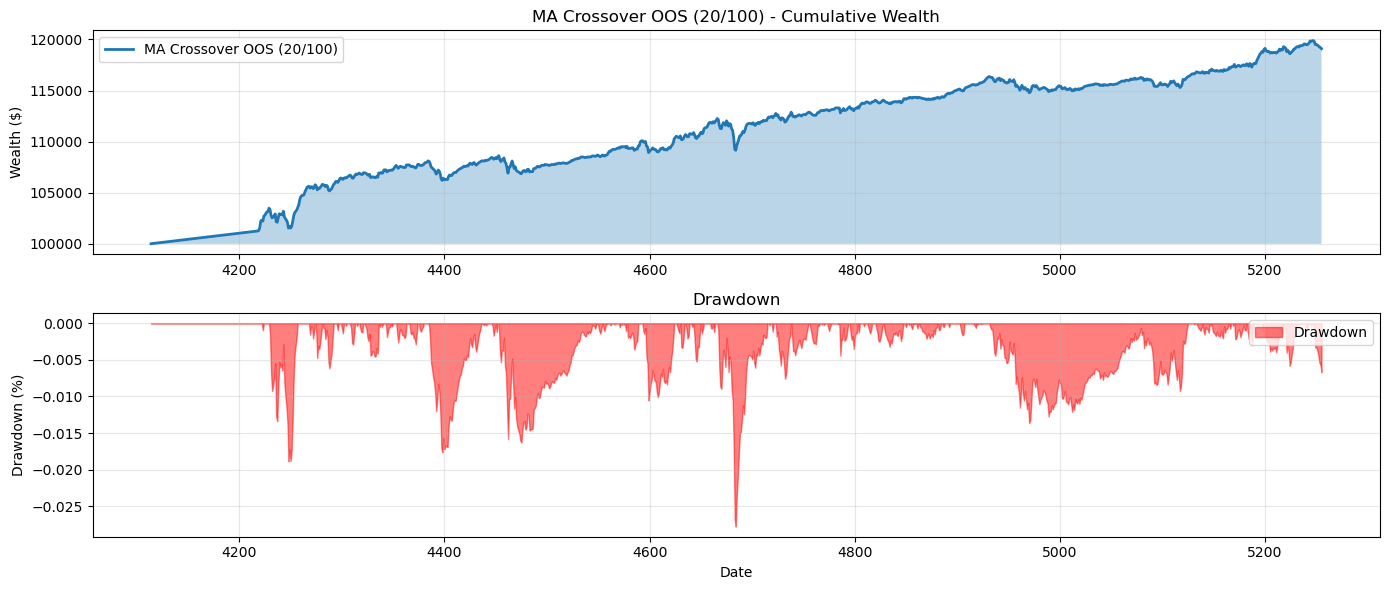


MA Crossover OOS (20/100) - Performance Summary:
  Sharpe Ratio: 0.419
  Annualized Return: 3.93%
  Max Drawdown: -2.78%
  Calmar Ratio: 1.417
                                    IS          OOS
--------------------------------------------------
OOS t-stat                                     3.94
Sharpe                          -0.277        0.419
OOS/IS Sharpe                                   nan
Mean Return                      2.35%        3.88%
Return Gap (IS-OOS)                          -1.53%
Max Drawdown                     -5.5%        -2.8%
Annual Turnover                              523.7%
Sharpe After Cost                             0.168
Max Recovery Days                               193
Rolling Sharpe Stability                      0.578


In [168]:
# Extract returns and weights for evaluation
returns_is = result_ma_is["portfolio_returns"]
returns_oos = result_ma_oos["portfolio_returns"]
weights_oos = result_ma_oos["weights"]

print(f'\n{result_ma_oos["name"]}:selected {best_ma["asset"]}, achieving sharpe {result_ma_oos["metrics"]["sharpe_ratio"]:.3f}')
name_oos = f'MA Crossover OOS ({best_ma["short_window"]}/{best_ma["long_window"]})'
bt_oos.plot_backtest(name_oos)

# Production Readiness Evaluation
eval_ma = evaluate_production_readiness(returns_is, returns_oos, weights_oos)

##### Breakout

In [173]:
def tune_bo_on_train(train_prices, candidate_grid):
    best = None
    best_score = -np.inf
    
    summary, candidates = select_bo_candidates(train_prices, train_prices.columns)
    show_bo(summary, candidates)

    candidates = [i for i, _ in candidates]
    selected_prices = train_prices[candidates] # Asset selection

    simple_ret  = selected_prices.pct_change().fillna(0) # simple return
    log_ret = np.log(selected_prices).diff().fillna(0) # log return

    for lookback, rebalance_freq in candidate_grid:
        # for sig_window, vol_window in list(itertools.product([10,20,60], [20,60,120]))：
            signals = donchian_breakout_signal(selected_prices, lookback=lookback)
            weights, _ = compute_portfolio_weights(
                log_ret,
                signals,
                method= "signal_inverse_vol",
                rebalance_freq=rebalance_freq, 
                window=60,
            )

            strat_ret = calculate_portfolio_returns(weights, simple_ret)
            score = calmar_ratio(strat_ret)

            if pd.notna(score) and score > best_score:
                best_score = score
                best = {
                    "asset": candidates,
                    "lookback": lookback,
                    "rebalance_freq": rebalance_freq,
                    "score": score,
                }

    return best

# asset selection + parameter selection(short-term, medium-term, mid-long trend, annual trend)
best_bo = tune_bo_on_train(train_prices, [(20, "monthly",), (55, "monthly"), (60, "monthly"), (120, "monthly"),(252, "monthly")])

# In-sample evaluation on train_prices
bt1_is = PortfolioBacktest(train_prices[best_bo["asset"]], initial_capital=100000)
result_bo_is = bt1_is.run_backtest(
    donchian_breakout_signal,
    allocation_method="signal_inverse_vol",
    strategy_kwargs={'lookback': best_bo["lookback"]},
    allocation_kwargs = {'rebalance_freq': best_bo["rebalance_freq"]
                        },
    name=f'Breakout IS ({best_bo["lookback"]}/{best_bo["rebalance_freq"]})'
)

# Out-of-sample evaluation on test_prices
bt1_oos = PortfolioBacktest(test_prices[best_bo["asset"]], initial_capital=100000)
result_bo_oos = bt1_oos.run_backtest(
    donchian_breakout_signal,
    allocation_method="signal_inverse_vol",
    strategy_kwargs={'lookback': best_bo["lookback"]},
    allocation_kwargs = {'rebalance_freq': best_bo["rebalance_freq"]
                        },
    name=f'Breakout OOS ({best_bo["lookback"]}/{best_bo["rebalance_freq"]})'
)



BO CANDIDATES:

Asset             Hurst   Trend AC     BO Hit   Width OK  Tail Ratio      Score
----------------------------------------------------------------------
guitars           0.592      0.736      0.569      1.000       3.440      5.514
gurkor            0.556      0.741      0.519      1.000       3.190     -0.324
water             0.569      0.739      0.514      1.000       3.086     -0.609
slingshots        0.570      0.720      0.505      1.000       3.033     -4.580



Breakout OOS (60/monthly):selected ['guitars', 'gurkor', 'water', 'slingshots'], achieving sharpe 0.368


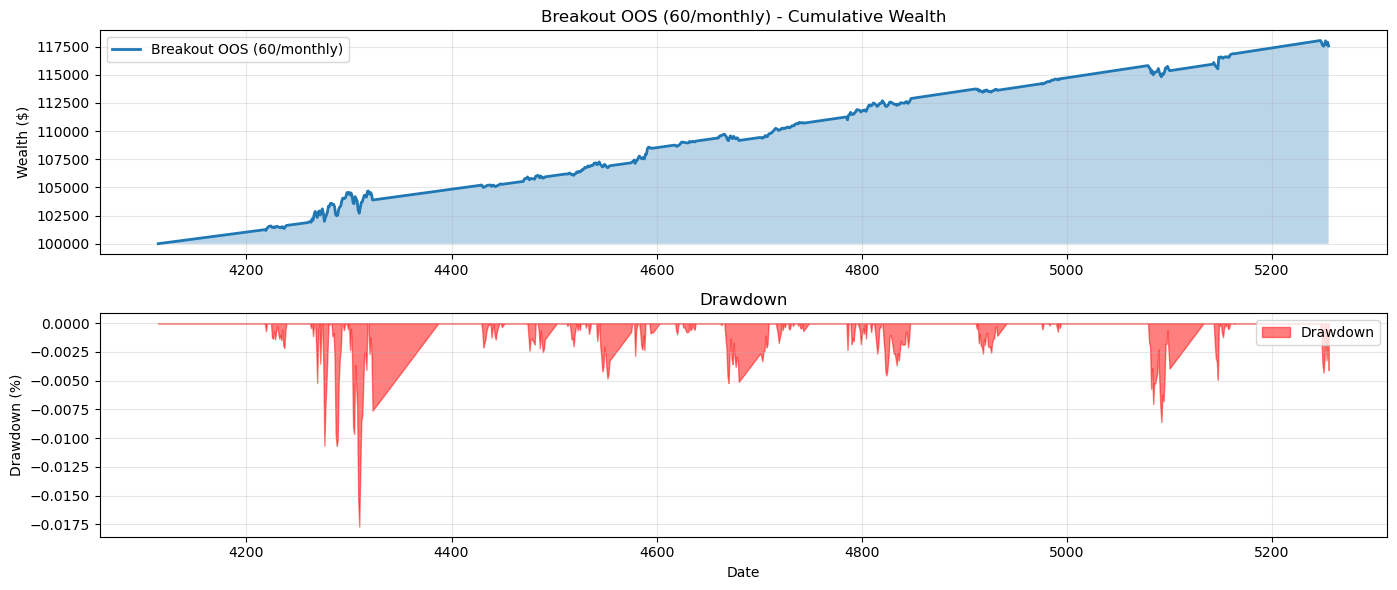


Breakout OOS (60/monthly) - Performance Summary:
  Sharpe Ratio: 0.368
  Annualized Return: 3.64%
  Max Drawdown: -1.77%
  Calmar Ratio: 2.053
                                    IS          OOS
--------------------------------------------------
OOS t-stat                                     4.81
Sharpe                           0.035        0.368
OOS/IS Sharpe                                 10.53
Mean Return                      3.05%        3.58%
Return Gap (IS-OOS)                          -0.53%
Max Drawdown                     -1.6%        -1.8%
Annual Turnover                              809.9%
Sharpe After Cost                            -0.140
Max Recovery Days                                68
Rolling Sharpe Stability                      0.875


In [174]:
# Extract returns and weights for evaluation
returns_is_bo = result_bo_is["portfolio_returns"]
returns_oos_bo = result_bo_oos["portfolio_returns"]
weights_oos_bo = result_bo_oos["weights"]

print(f'\n{result_bo_oos["name"]}:selected {best_bo["asset"]}, achieving sharpe {result_bo_oos["metrics"]["sharpe_ratio"]:.3f}')
name1_oos=f'Breakout OOS ({best_bo["lookback"]}/{best_bo["rebalance_freq"]})'
bt1_oos.plot_backtest(name1_oos)

eval_bo = evaluate_production_readiness(returns_is_bo, returns_oos_bo, weights_oos_bo)